# Introduction
In this first notebook of our project:
* We are going to acquire hourly raw weather data from [Open-Meteo API](https://open-meteo.com/en/docs/historical-weather-api),
* merge and save the data,
* make initial quality control of the data.

# Selected Variables
| Variable | Unit | Meaning |
| :-- | :--: | :-- |
| temperature_2m | $\degree \text{C}$ | Air temperature at 2 m above ground | 
| relative_humidity_2m | $\%$ | Near-surface relative humidity | 
| dew_point_2m | $\degree \text{C}$ | Dew point temperature at 2 m | 
| apparent_temperature | $\degree \text{C}$ | Perceived “feels-like” temperature | 
| precipitation | $\text{mm}$ | Total precipitation (hourly sum) | 
| pressure_msl | $\text{hPa}$ | Mean sea-level air pressure | 
| wind_speed_10m | $\text{m/s}$ | Wind speed at 10 m | 
| wind_direction_10m | $\degree$ | Wind direction at 10 m | 
| cloud_cover | $\%$ | Total cloud cover | 
| shortwave_radiation | $\text{W/m}^2$ | Incoming shortwave solar radiation | 
| wet_bulb_temperature_2m | $\degree \text{C}$ | Wet-bulb temperature at 2 m | 

**!** Full variable definitions and measurement details are provided by the [Open-Meteo API documentation](https://open-meteo.com/en/docs/historical-weather-api#hourly_parameter_definition).



# Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.data_utils import fetch_hourly_weather_range
from src.plotting_utils import plot_with_time_range

# Hourly Weather Data Fetching 

In [ ]:
# Variables to fetch
HOURLY_VARS = [
    "temperature_2m",
    "relative_humidity_2m",
    "dew_point_2m",
    "apparent_temperature",
    "precipitation",
    "pressure_msl",
    "wind_speed_10m",
    "wind_direction_10m",
    "cloud_cover",
    "shortwave_radiation",
    "wet_bulb_temperature_2m",
]

In [ ]:
# Fetch in short intervals to reduce API timeouts and partial failures
df_1 = fetch_hourly_weather_range(
    start_year=2020,
    end_year=2022,
    hourly_vars=HOURLY_VARS,
    save_path=None
)

Fetching 2020-01-01 → 2020-06-30 ...
Success: 2020-01-01 → 2020-06-30 (4368 rows)
Fetching 2020-07-01 → 2020-12-31 ...
Success: 2020-07-01 → 2020-12-31 (4416 rows)
Fetching 2021-01-01 → 2021-06-30 ...
Success: 2021-01-01 → 2021-06-30 (4344 rows)
Fetching 2021-07-01 → 2021-12-31 ...
Success: 2021-07-01 → 2021-12-31 (4416 rows)
Fetching 2022-01-01 → 2022-06-30 ...
Success: 2022-01-01 → 2022-06-30 (4344 rows)
Fetching 2022-07-01 → 2022-12-31 ...
Success: 2022-07-01 → 2022-12-31 (4416 rows)


In [4]:
df_1.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 26304 entries, 2019-12-31 13:30:00 to 2022-12-31 12:30:00
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   temperature_2m           26304 non-null  float32
 1   relative_humidity_2m     26304 non-null  float32
 2   dew_point_2m             26304 non-null  float32
 3   apparent_temperature     26304 non-null  float32
 4   precipitation            26304 non-null  float32
 5   pressure_msl             26304 non-null  float32
 6   wind_speed_10m           26304 non-null  float32
 7   wind_direction_10m       26304 non-null  float32
 8   cloud_cover              26304 non-null  float32
 9   shortwave_radiation      26304 non-null  float32
 10  wet_bulb_temperature_2m  26304 non-null  float32
dtypes: float32(11)
memory usage: 1.3 MB


In [ ]:
df_1.head() 

,temperature_2m,relative_humidity_2m,dew_point_2m,apparent_temperature,precipitation,pressure_msl,wind_speed_10m,wind_direction_10m,cloud_cover,shortwave_radiation,wet_bulb_temperature_2m
datetime,,,,,,,,,,,
2019-12-31 13:30:00,14.937500,64.010033,8.187500,13.310396,0.0,1016.500000,7.903619,120.068497,0.0,0.0,10.903521
2019-12-31 14:30:00,14.337500,68.596054,8.637500,12.883753,0.0,1016.099976,7.517021,106.699326,0.0,0.0,10.852879
2019-12-31 15:30:00,13.337500,76.735092,9.337500,12.288231,0.0,1015.700012,6.034700,107.354111,0.0,0.0,10.785607
2019-12-31 16:30:00,12.537499,84.458443,9.987499,11.702080,0.0,1015.700012,5.815978,111.801476,0.0,0.0,10.832471
2019-12-31 17:30:00,12.387500,87.311943,10.337500,11.699740,0.0,1015.900024,5.495161,121.607460,0.0,0.0,10.987007


In [7]:
df_1.tail()

,temperature_2m,relative_humidity_2m,dew_point_2m,apparent_temperature,precipitation,pressure_msl,wind_speed_10m,wind_direction_10m,cloud_cover,shortwave_radiation,wet_bulb_temperature_2m
datetime,,,,,,,,,,,
2022-12-31 08:30:00,26.887499,46.125343,14.3375,25.850292,0.0,1008.099976,16.831684,138.468323,0.0,245.0,18.979305
2022-12-31 09:30:00,24.287500,50.604866,13.3875,23.055614,0.0,1008.400024,15.856354,129.472427,0.0,58.0,17.477373
2022-12-31 10:30:00,22.637499,51.507847,12.1375,20.622692,0.0,1008.400024,18.359999,118.072395,0.0,0.0,16.184753
2022-12-31 11:30:00,21.537500,50.879166,10.9375,19.054089,0.0,1007.900024,19.008545,127.304031,0.0,0.0,15.144390
2022-12-31 12:30:00,20.987499,48.901783,9.8375,18.172358,0.0,1007.799988,19.083395,125.789062,0.0,0.0,14.396236


When we look to beginning and end of dates, we see a 11-12 hours time shift. This occurs due to timezone differences. While we merge the data, we need to be keeping this in mind.

In [ ]:
df_1.to_csv("data/raw/adelaide_hourly_weather_2020_2022.csv") # save data to local as .csv

In [ ]:
# One more short duration test for possible errors
df_2 = fetch_hourly_weather_range(
    start_year=2023,
    end_year=2024,
    hourly_vars=HOURLY_VARS,
    save_path=None
)
df_2.to_csv("data/raw/adelaide_hourly_weather_2023_2024.csv")

Fetching 2023-01-01 → 2023-06-30 ...
Success: 2023-01-01 → 2023-06-30 (4344 rows)
Fetching 2023-07-01 → 2023-12-31 ...
Success: 2023-07-01 → 2023-12-31 (4416 rows)
Fetching 2024-01-01 → 2024-06-30 ...
Success: 2024-01-01 → 2024-06-30 (4368 rows)
Fetching 2024-07-01 → 2024-12-31 ...
Success: 2024-07-01 → 2024-12-31 (4416 rows)


In [15]:
df_2.index.max(), df_2.index.min(), df_1.index.max(), df_1.index.min()

(Timestamp('2024-12-31 12:30:00'),
 Timestamp('2022-12-31 13:30:00'),
 Timestamp('2022-12-31 12:30:00'),
 Timestamp('2019-12-31 13:30:00'))

Okay, timezone shifts actually completes each other. As long as we keep requested intervals correct, any time gap would be covered.

In [16]:
df_3 = fetch_hourly_weather_range(
    start_year=2015,
    end_year=2019,
    hourly_vars=HOURLY_VARS,
    save_path=None
)
df_3.to_csv("data/raw/adelaide_hourly_weather_2015_2019.csv")

Fetching 2015-01-01 → 2015-06-30 ...
Success: 2015-01-01 → 2015-06-30 (4344 rows)
Fetching 2015-07-01 → 2015-12-31 ...
Success: 2015-07-01 → 2015-12-31 (4416 rows)
Fetching 2016-01-01 → 2016-06-30 ...
Success: 2016-01-01 → 2016-06-30 (4368 rows)
Fetching 2016-07-01 → 2016-12-31 ...
Success: 2016-07-01 → 2016-12-31 (4416 rows)
Fetching 2017-01-01 → 2017-06-30 ...
Success: 2017-01-01 → 2017-06-30 (4344 rows)
Fetching 2017-07-01 → 2017-12-31 ...
Success: 2017-07-01 → 2017-12-31 (4416 rows)
Fetching 2018-01-01 → 2018-06-30 ...
Success: 2018-01-01 → 2018-06-30 (4344 rows)
Fetching 2018-07-01 → 2018-12-31 ...
Success: 2018-07-01 → 2018-12-31 (4416 rows)
Fetching 2019-01-01 → 2019-06-30 ...
Success: 2019-01-01 → 2019-06-30 (4344 rows)
Fetching 2019-07-01 → 2019-12-31 ...
Success: 2019-07-01 → 2019-12-31 (4416 rows)


In [17]:
df_4 = fetch_hourly_weather_range(
    start_year=2004,
    end_year=2014,
    hourly_vars=HOURLY_VARS,
    save_path=None
)
df_4.to_csv("data/raw/adelaide_hourly_weather_2004_2014.csv")

Fetching 2004-01-01 → 2004-06-30 ...
Success: 2004-01-01 → 2004-06-30 (4368 rows)
Fetching 2004-07-01 → 2004-12-31 ...
Success: 2004-07-01 → 2004-12-31 (4416 rows)
Fetching 2005-01-01 → 2005-06-30 ...
Success: 2005-01-01 → 2005-06-30 (4344 rows)
Fetching 2005-07-01 → 2005-12-31 ...
Success: 2005-07-01 → 2005-12-31 (4416 rows)
Fetching 2006-01-01 → 2006-06-30 ...
Success: 2006-01-01 → 2006-06-30 (4344 rows)
Fetching 2006-07-01 → 2006-12-31 ...
Success: 2006-07-01 → 2006-12-31 (4416 rows)
Fetching 2007-01-01 → 2007-06-30 ...
Success: 2007-01-01 → 2007-06-30 (4344 rows)
Fetching 2007-07-01 → 2007-12-31 ...
Success: 2007-07-01 → 2007-12-31 (4416 rows)
Fetching 2008-01-01 → 2008-06-30 ...
Success: 2008-01-01 → 2008-06-30 (4368 rows)
Fetching 2008-07-01 → 2008-12-31 ...
Success: 2008-07-01 → 2008-12-31 (4416 rows)
Fetching 2009-01-01 → 2009-06-30 ...
Success: 2009-01-01 → 2009-06-30 (4344 rows)
Fetching 2009-07-01 → 2009-12-31 ...
Success: 2009-07-01 → 2009-12-31 (4416 rows)
Fetching 2010-01

# Merging Data Chunks
All required data has been fetched. Now, we need to merge the data.

In [63]:
df_1 = pd.read_csv("data/raw/adelaide_hourly_weather_2020_2022.csv", parse_dates=["datetime"], index_col="datetime")
df_2 = pd.read_csv("data/raw/adelaide_hourly_weather_2023_2024.csv", parse_dates=["datetime"], index_col="datetime")
df_3 = pd.read_csv("data/raw/adelaide_hourly_weather_2015_2019.csv", parse_dates=["datetime"], index_col="datetime")
df_4 = pd.read_csv("data/raw/adelaide_hourly_weather_2004_2014.csv", parse_dates=["datetime"], index_col="datetime")

In [17]:
# Checking chunk date starts and ends
print("2004-2014 interval:", df_4.index.min(), "--", df_4.index.max()) 
print("2015-2019 interval:", df_3.index.min(), "--", df_3.index.max())
print("2020-2022 interval:", df_1.index.min(), "--", df_1.index.max())
print("2023-2024 interval:", df_2.index.min(), "--", df_2.index.max())

2004-2014 interval: 2003-12-31 13:30:00 -- 2014-12-31 12:30:00
2015-2019 interval: 2014-12-31 13:30:00 -- 2019-12-31 12:30:00
2020-2022 interval: 2019-12-31 13:30:00 -- 2022-12-31 12:30:00
2023-2024 interval: 2022-12-31 13:30:00 -- 2024-12-31 12:30:00


All time starting and ending dates match, we can now merge the data.

In [64]:
raw_all_df = pd.concat([df_4, df_3, df_1, df_2], axis=0)
raw_all_df.to_csv("data/raw/adelaide_hourly_weather_2004_2024.csv")
raw_all_df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 184104 entries, 2003-12-31 13:30:00 to 2024-12-31 12:30:00
Data columns (total 11 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   temperature_2m           184104 non-null  float64
 1   relative_humidity_2m     184104 non-null  float64
 2   dew_point_2m             184104 non-null  float64
 3   apparent_temperature     184104 non-null  float64
 4   precipitation            184104 non-null  float64
 5   pressure_msl             184104 non-null  float64
 6   wind_speed_10m           184104 non-null  float64
 7   wind_direction_10m       184104 non-null  float64
 8   cloud_cover              184104 non-null  float64
 9   shortwave_radiation      184104 non-null  float64
 10  wet_bulb_temperature_2m  184104 non-null  float64
dtypes: float64(11)
memory usage: 16.9 MB


Our data has no missing values due to our data source [open-meteo](https://open-meteo.com/) gathers, compiles and validates the data from multiple sources. Let's make a quick look at the data in case of it might have still other issues. 

In [ ]:
# Loading cell for later use
raw_all_df = pd.read_csv("data/raw/adelaide_hourly_weather_2004_2024.csv", parse_dates=["datetime"], index_col="datetime")
raw_all_df.head()

,temperature_2m,relative_humidity_2m,dew_point_2m,apparent_temperature,precipitation,pressure_msl,wind_speed_10m,wind_direction_10m,cloud_cover,shortwave_radiation,wet_bulb_temperature_2m
datetime,,,,,,,,,,,
2003-12-31 13:30:00,19.189999,62.846900,11.940001,17.814700,0.0,1013.6,13.551500,163.00910,0.0,0.0,14.638624
2003-12-31 14:30:00,18.390000,67.164460,12.190001,17.394241,0.0,1013.3,11.503113,159.86362,0.0,0.0,14.437140
2003-12-31 15:30:00,17.740000,71.356514,12.490001,17.008575,0.0,1012.8,10.365251,159.67677,0.0,0.0,14.335859
2003-12-31 16:30:00,17.189999,75.343920,12.790000,16.558638,0.0,1012.8,10.365251,159.67677,0.0,0.0,14.287519
2003-12-31 17:30:00,16.640000,79.822290,13.140000,16.225534,0.0,1013.1,9.693296,158.19853,0.0,0.0,14.282982


# Initial Quality Control

In this section, we are goingt to have a quick glance at the data if there is any potential issues.

**! Note About Plots:** In this notebook we've replaced all `plot_with_time_range()` cell outputs with their images, due to each one of their original sizes are too large to upload to GitHub. To display original plots, anyone should run the cell one above that loads `raw_all_df` merged full raw data, and then run sequentiall executive code cells. Reason is almost all `plot_with_time_range()` cells use `datetime_local` column as index and it is generated on the run.

In [3]:
pd.Series(raw_all_df.index).nunique(), len(pd.date_range(start=raw_all_df.index.min(), end=raw_all_df.index.max(), freq="h"))

(184104, 184104)

Data has no duplicate dates or temporal gaps. Let's have a quick look the boundries of variables.

In [4]:
raw_all_df.describe()

,temperature_2m,relative_humidity_2m,dew_point_2m,apparent_temperature,precipitation,pressure_msl,wind_speed_10m,wind_direction_10m,cloud_cover,shortwave_radiation,wet_bulb_temperature_2m
count,184104.000000,184104.000000,184104.000000,184104.000000,184104.000000,184104.000000,184104.000000,184104.000000,184104.000000,184104.000000,184104.000000
mean,16.540090,64.846082,8.939005,14.278202,0.059213,1017.651574,15.657457,174.225257,45.288478,210.439789,12.044428
std,6.042069,19.686475,3.509425,6.813030,0.301786,7.108914,7.701780,92.946627,38.240093,295.688958,3.599881
min,1.137500,6.456486,-14.462501,-1.427589,0.000000,979.700000,0.000000,0.451139,0.000000,0.000000,0.220225
25%,12.187500,51.038956,6.587500,9.241866,0.000000,1012.800000,9.826088,101.888630,4.000000,0.000000,9.421764
50%,15.340000,67.214250,8.840000,12.961634,0.000000,1017.500000,14.843180,176.308690,41.000000,9.000000,11.770336
75%,19.939999,80.896658,11.190001,18.255994,0.000000,1022.500000,20.598795,239.036300,86.000000,380.000000,14.451913
max,42.737503,100.000000,24.187500,43.602524,26.600000,1039.400000,62.612057,360.000000,100.000000,1116.000000,26.712038


In terms of *mean, std, min, max*, variables are looking good. Let's have a look at plots to check for any other anomalies or issues.

In [ ]:
plot_with_time_range(raw_all_df, "temperature_2m")

![image](plot_img/01_temperature_timezone_shift.png)

As we can see, there is a temporal shift: Day hours and the temperature values are not reasonable. This happens because our datetime values are in UTC timezone. We are going to keep our index in UTC timezone. Also for convenience during analysis, we'll derive a local datetime, date, hour, and month columns.

In [20]:
raw_all_df.index = raw_all_df.index.tz_localize("UTC")
print(raw_all_df.index.tz)

UTC


In [21]:
raw_all_df["datetime_local"] = raw_all_df.index.tz_convert("Australia/Adelaide")
raw_all_df['datetime_local'].head()

datetime
2003-12-31 13:30:00+00:00   2004-01-01 00:00:00+10:30
2003-12-31 14:30:00+00:00   2004-01-01 01:00:00+10:30
2003-12-31 15:30:00+00:00   2004-01-01 02:00:00+10:30
2003-12-31 16:30:00+00:00   2004-01-01 03:00:00+10:30
2003-12-31 17:30:00+00:00   2004-01-01 04:00:00+10:30
Name: datetime_local, dtype: datetime64[ns, Australia/Adelaide]

In [22]:
raw_all_df["date_local"] = raw_all_df["datetime_local"].dt.date
raw_all_df["hour_local"] = raw_all_df["datetime_local"].dt.hour
raw_all_df["month_local"] = raw_all_df["datetime_local"].dt.month
raw_all_df[['datetime_local', 'date_local', 'hour_local', 'month_local']].head()

,datetime_local,date_local,hour_local,month_local
datetime,,,,
2003-12-31 13:30:00+00:00,2004-01-01 00:00:00+10:30,2004-01-01,0,1
2003-12-31 14:30:00+00:00,2004-01-01 01:00:00+10:30,2004-01-01,1,1
2003-12-31 15:30:00+00:00,2004-01-01 02:00:00+10:30,2004-01-01,2,1
2003-12-31 16:30:00+00:00,2004-01-01 03:00:00+10:30,2004-01-01,3,1
2003-12-31 17:30:00+00:00,2004-01-01 04:00:00+10:30,2004-01-01,4,1


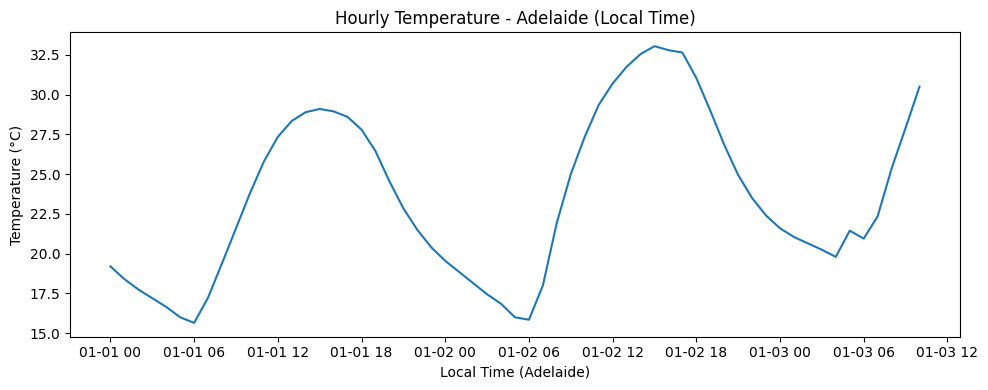

In [23]:
# Demo of using local time
sample = raw_all_df.loc["2003-12-31 13:30:00+00:00":"2004-01-03 00:00:00+00:00"].copy()

plt.figure(figsize=(10, 4))
plt.plot(sample["datetime_local"], sample["temperature_2m"])
plt.xlabel("Local Time (Adelaide)")
plt.ylabel("Temperature (°C)")
plt.title("Hourly Temperature - Adelaide (Local Time)")
plt.tight_layout()
plt.show()

Temporal shift problem is fixed.

In [87]:
raw_all_df.to_csv("data/processed/adelaide_hourly_weather.csv", index=True, index_label="datetime_utc")

In [4]:
raw_all_df = pd.read_csv(
    "data/processed/adelaide_hourly_weather.csv",
    parse_dates=["datetime_utc"],
    index_col="datetime_utc"
)
raw_all_df["datetime_local"] = raw_all_df.index.tz_convert("Australia/Adelaide")
# ! Pandas will not parse 'datetime_local' properly. Thus we reproduce it manually.
raw_all_df.head()

,temperature_2m,relative_humidity_2m,dew_point_2m,apparent_temperature,precipitation,pressure_msl,wind_speed_10m,wind_direction_10m,cloud_cover,shortwave_radiation,wet_bulb_temperature_2m,datetime_local,date_local,hour_local,month_local
datetime_utc,,,,,,,,,,,,,,,
2003-12-31 13:30:00+00:00,19.189999,62.846900,11.940001,17.814700,0.0,1013.6,13.551500,163.00910,0.0,0.0,14.638624,2004-01-01 00:00:00+10:30,2004-01-01,0,1
2003-12-31 14:30:00+00:00,18.390000,67.164460,12.190001,17.394241,0.0,1013.3,11.503113,159.86362,0.0,0.0,14.437140,2004-01-01 01:00:00+10:30,2004-01-01,1,1
2003-12-31 15:30:00+00:00,17.740000,71.356514,12.490001,17.008575,0.0,1012.8,10.365251,159.67677,0.0,0.0,14.335859,2004-01-01 02:00:00+10:30,2004-01-01,2,1
2003-12-31 16:30:00+00:00,17.189999,75.343920,12.790000,16.558638,0.0,1012.8,10.365251,159.67677,0.0,0.0,14.287519,2004-01-01 03:00:00+10:30,2004-01-01,3,1
2003-12-31 17:30:00+00:00,16.640000,79.822290,13.140000,16.225534,0.0,1013.1,9.693296,158.19853,0.0,0.0,14.282982,2004-01-01 04:00:00+10:30,2004-01-01,4,1


Let's continue checking column plots for any other issues.

In [ ]:
plot_with_time_range(raw_all_df, "relative_humidity_2m", x_axis='datetime_local')

![image](plot_img/01_relative_humidity_2m.png)

In [ ]:
plot_with_time_range(raw_all_df, "dew_point_2m", x_axis='datetime_local')

![image](plot_img/01_dew_point_2m_outlier.png)

**!** There might be a sensor issue around *"2019-December-25"* or just a an outlier. We'll check this later.

In [ ]:
plot_with_time_range(raw_all_df, "apparent_temperature", x_axis='datetime_local')

![image](plot_img/01_apparent_temperature.png)

In [ ]:
plot_with_time_range(raw_all_df, "precipitation", x_axis='datetime_local')

![image](plot_img/01_precipitation_outlier.png)

**!** Precipitation should be checked in case of sensor issue / outliers. Especially *2020-February-01*.

In [ ]:
plot_with_time_range(raw_all_df, "pressure_msl", x_axis='datetime_local')

![image](plot_img/01_pressure_msl_outlier.png)

**!** *Sea Level Pressure* might be has either several sensor issues or outliers: *2016-September-29*, *2022-May-29*. We'll check those later.

In [ ]:
plot_with_time_range(raw_all_df, "wind_speed_10m", x_axis='datetime_local')

![image](plot_img/01_wind_speed_10m.png)

In [ ]:
plot_with_time_range(raw_all_df, "wind_direction_10m", x_axis='datetime_local')

![image](plot_img/01_wind_direction_10m.png)

**!** This much volatility in wind direction is expected due to its unit which is degree. As a natural phenomenon, wind direction changes a lot over time. We'll derive 8 compass directions and unit vector direction version of this variable later. This should be done because of variable is cyclical. Which means 1 degree and 360 degree side by side, but numerically it is not in this format.

In [ ]:
plot_with_time_range(raw_all_df, "cloud_cover", x_axis='datetime_local')

![image](plot_img/01_cloud_cover.png)

In [ ]:
plot_with_time_range(raw_all_df, "shortwave_radiation", x_axis='datetime_local')

![image](plot_img/01_shortwave_radiation.png)

In [ ]:
plot_with_time_range(raw_all_df, "wet_bulb_temperature_2m", x_axis='datetime_local')

![image](plot_img/01_wet_bulb_temperature_2m.png)

# Goals for the Next Notebook
## Potential Issues to Be Checked 

**Potential Sensor Associated Issues:**
* `dew_point_2m`: *"2019-December-25"*
* `precipitation`: *"2020-February-01"*
* `pressure_msl`: *"2016-September-29", "2022-May-29"*

## Additional Modifications to Be Made
* Wind direction: 8 compass directions and unit vector direction columns are going to be derived from the original wind direction column.

Issues and modifications have been noted. They are going to be addressed in the next notebook: **02_data_cleaning_and_preparation.ipynb**.